# knowledge domain
****************************
## Dataset Information
This database contains 12 attributes describing patients’ demographic data, medical examination results, and lifestyle habits.
The objective is to predict the presence or absence of cardiovascular disease, recorded in the field cardio (binary: 0 = no disease, 1 = disease).
All values were collected at the time of a routine medical examination.

## Features are grouped as follows:

### Objective features – factual information provided by measurement or record

Age (age): integer, patient age in __days__

Height (height): integer, in centimeters

Weight (weight): float, in kilograms

Gender (gender): categorical code (1 = female, 2 = male)

### Examination features – results from clinical measurements

Systolic blood pressure (ap_hi): integer (mm Hg)

Diastolic blood pressure (ap_lo): integer (mm Hg)

Cholesterol (cholesterol): categorical (1 = normal, 2 = above normal, 3 = well above normal)

Glucose (gluc): categorical (1 = normal, 2 = above normal, 3 = well above normal)

Subjective features – self-reported lifestyle habits

Smoking (smoke): binary (0 = no, 1 = yes)

Alcohol intake (alco): binary (0 = no, 1 = yes)

Physical activity (active): binary (0 = no, 1 = yes)

### Target variable

Cardiovascular disease (cardio): binary (0 = no presence, 1 = presence)

## Dataset Composition
The dataset comprises 12 total attributes, divided into 11 input features and 1 target variable.
Each record represents a single medical examination of an adult patient.

+ Features: 12 input attributes + 1 target variable
+ Missing Data: no Missing Data


# developed by :
Team 1: 
١- عبدالرحمن محمد خليل 
٢- جنى شريف السعيد 
٣- عمر عبدالله بطل 
٤- عمر كريم سعيد
٥- أحمد هشام محمود

### import the necessary Library

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report , accuracy_score , confusion_matrix , f1_score , precision_score , recall_score

from sklearn.linear_model import LogisticRegression

In [76]:
df=pd.read_csv('cardio_train.csv')
df.head(5)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [77]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [79]:
df.select_dtypes(include="number").corr()['cardio']

id             0.003799
age            0.238159
gender         0.008109
height        -0.010821
weight         0.181660
ap_hi          0.054475
ap_lo          0.065719
cholesterol    0.221147
gluc           0.089307
smoke         -0.015486
alco          -0.007330
active        -0.035653
cardio         1.000000
Name: cardio, dtype: float64

In [80]:
df["weight"] = df["weight"].astype(int)
df.head(n=3)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62,110,80,1,1,0,0,1,0
1,1,20228,1,156,85,140,90,3,1,0,0,1,1
2,2,18857,1,165,64,130,70,3,1,0,0,0,1


### convert age from dayes to year

In [81]:
df["age"] = df["age"]//365.25
df.head(n=3)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.0,2,168,62,110,80,1,1,0,0,1,0
1,1,55.0,1,156,85,140,90,3,1,0,0,1,1
2,2,51.0,1,165,64,130,70,3,1,0,0,0,1


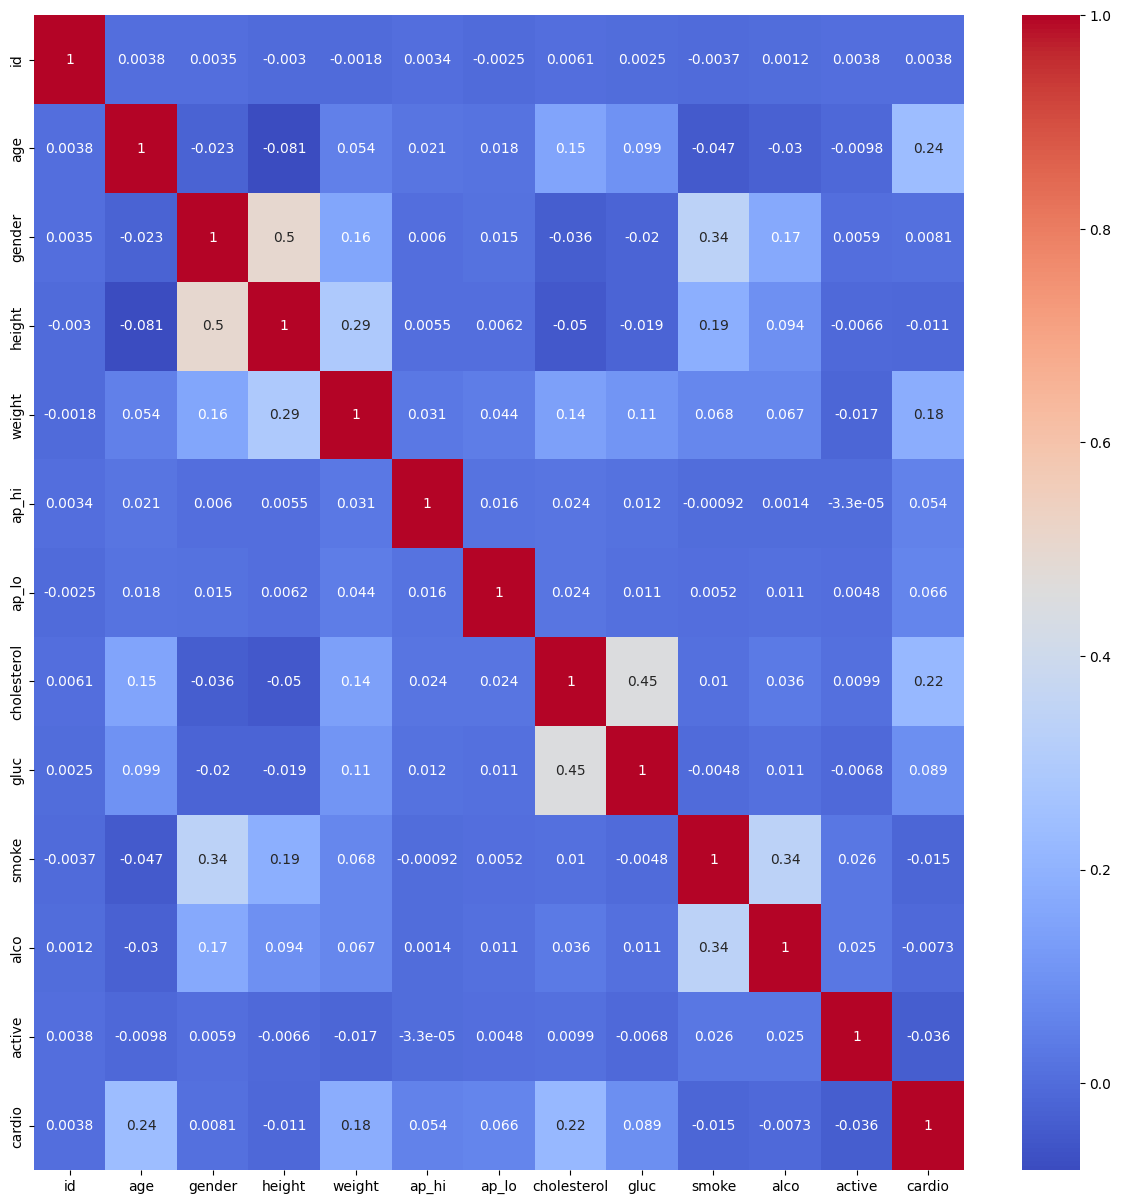

In [82]:
corr = df.select_dtypes(include="number").corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr , annot=True , cmap='coolwarm')
plt.show()

In [83]:
df.drop(columns='id',inplace=True)

### wrong input

In [84]:
print(df["ap_hi"][df["ap_hi"] < 0])
# solve
df = df.abs()

print("after solve ",df["ap_hi"][df["ap_hi"] < 0])


4607    -100
16021   -115
20536   -100
23988   -140
25240   -120
35040   -150
46627   -120
Name: ap_hi, dtype: int64
after solve  Series([], Name: ap_hi, dtype: int64)


### draw the histogram to check the distribution

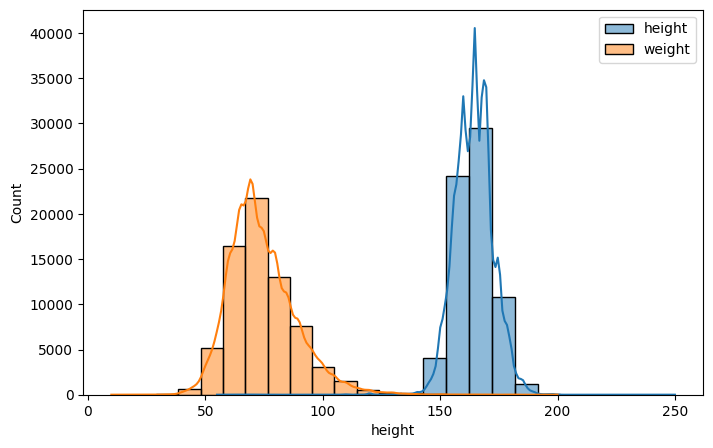

In [87]:
plt.figure(figsize=(8,5))
sns.histplot(df["height"] , bins=20 , kde=True ,label = "height")
sns.histplot(df["weight"] , bins=20 , kde=True , label= "weight")
plt.legend()
plt.show()


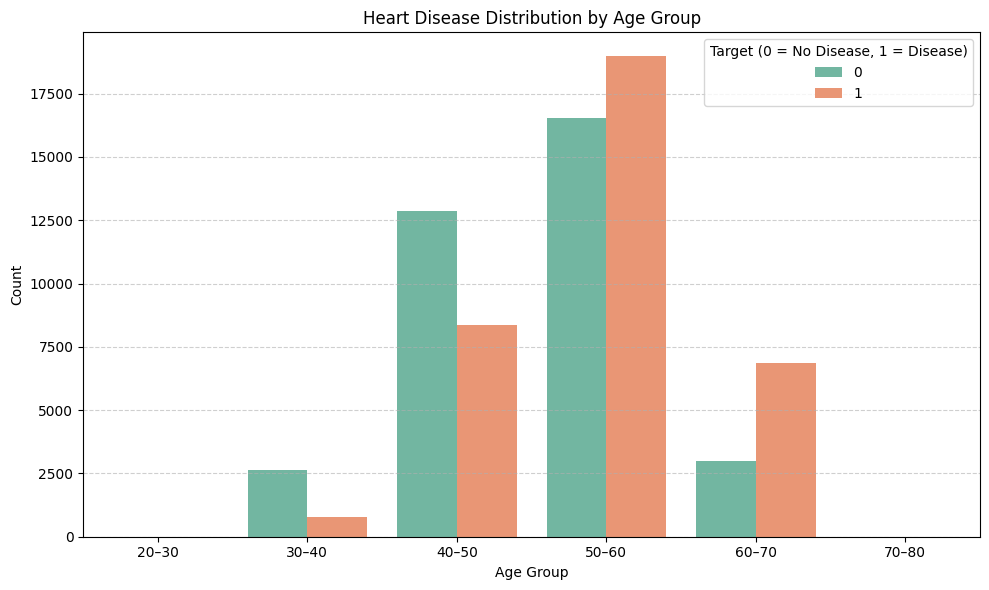

In [23]:
# Define age groups
bins = [20, 30, 40, 50, 60, 70, 80]
labels = ['20–30', '30–40', '40–50', '50–60', '60–70', '70–80']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='age_group', hue='cardio', palette='Set2')
plt.title('Heart Disease Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Target (0 = No Disease, 1 = Disease)')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# drop this column to Prevent the problem when we create the correlation matrix
df.drop(columns="age_group" , inplace=True)

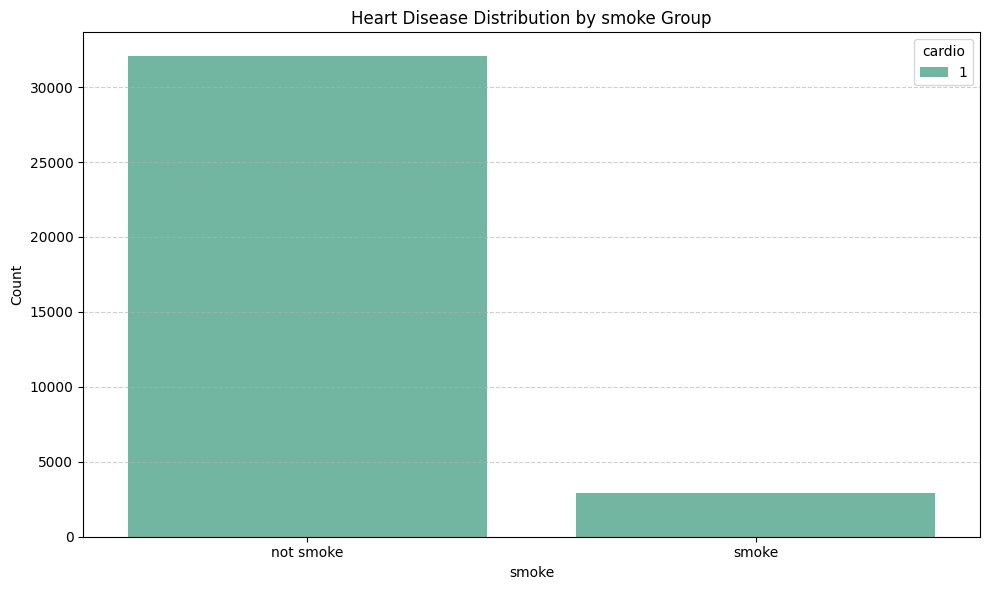

In [24]:
data = df.copy()
data = data[data["cardio"]==1]
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='smoke', hue='cardio', palette='Set2')
plt.title('Heart Disease Distribution by smoke Group')
plt.xlabel('smoke')
plt.ylabel('Count')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.xticks(np.arange(2),labels=["not smoke" , "smoke"])
plt.tight_layout()
plt.show()
del data # delete data form memory


### Categorical Features

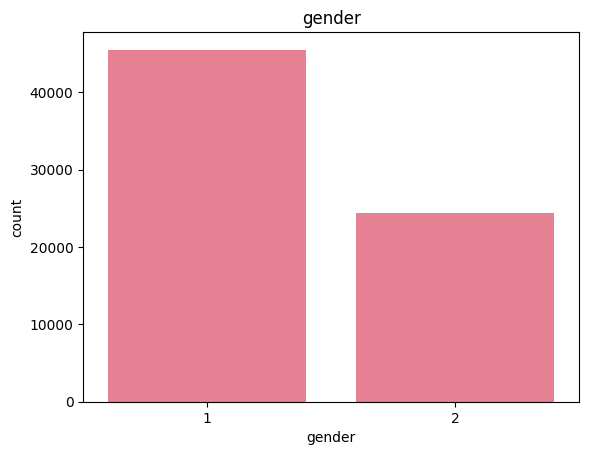

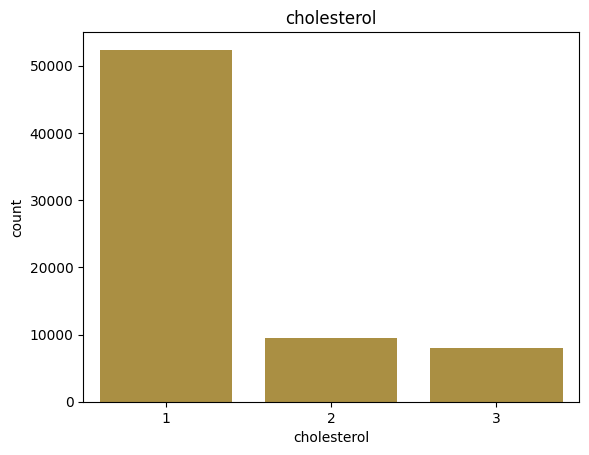

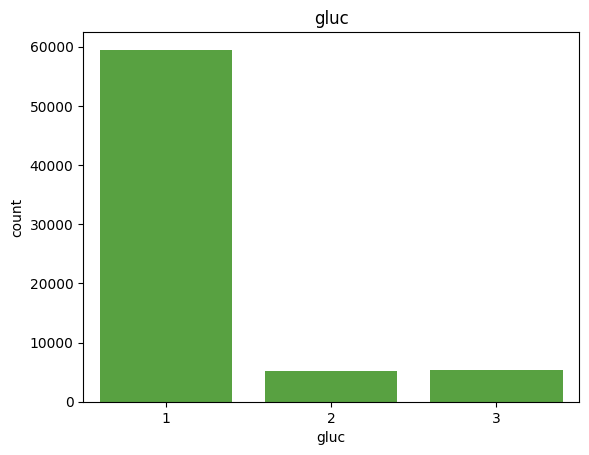

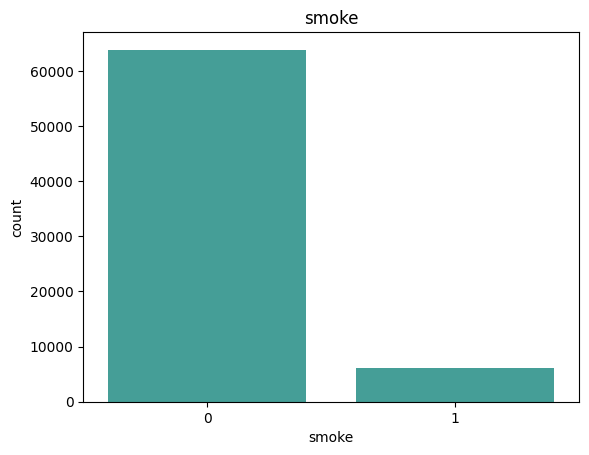

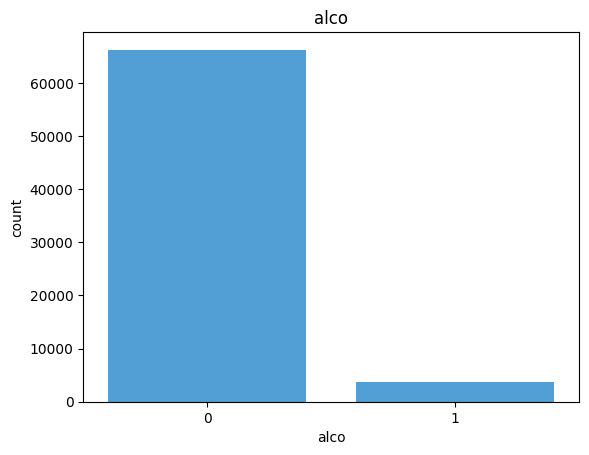

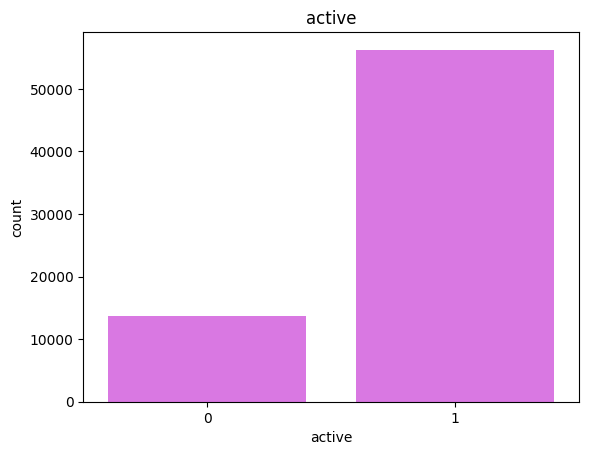

In [99]:
cat_cols = ['gender','cholesterol','gluc','smoke','alco','active']
colors = sns.color_palette("husl",n_colors=len(cat_cols))
for i,c in zip(range(len(cat_cols)),cat_cols):
    sns.countplot(x=c, data=df , color=colors[i])
    plt.title(c)
    plt.show()


In [1]:
print(df.dtypes)
df['cardio'].value_counts(normalize=True).plot(kind='bar', color='teal')
plt.title("Target Balance (cardio)")
plt.show()

NameError: name 'df' is not defined

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  int64  
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB


### use Recursive Feature Elimination (RFE) for feature selection

In [26]:
scale = RobustScaler()

In [2]:
x_train , x_test , y_train , y_test = train_test_split(df.drop(columns="cardio"),df["cardio"] , test_size=0.15 , random_state=40)
x_train = scale.fit_transform(x_train)
x_test = scale.fit_transform(x_test)
RFE = RFE(estimator=RandomForestClassifier())
featyre = RFE.fit(x_train,y_train)



NameError: name 'train_test_split' is not defined

In [49]:
selected_features_RFE = df.drop(columns='cardio').columns[featyre.support_]
print("Selected Features by RFE:\n", selected_features_RFE)

Selected Features by RFE:
 Index(['age', 'height', 'weight', 'ap_hi', 'ap_lo'], dtype='object')


###################################

In [53]:
models = {
    "adaBoost": {
        "model": AdaBoostClassifier(),
        "par": {
            "n_estimators": [50, 100, 200, 400, 800],
            "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
        }
    },

    "xgb": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
        "par": {
            "n_estimators": [100, 200, 400],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0]
        }
    },

    "lgbm": {
        "model": LGBMClassifier(),
        "par": {
            "n_estimators": [100, 200, 400],
            "max_depth": [-1, 10, 20],
            "learning_rate": [0.01, 0.05, 0.1],
            "num_leaves": [31, 63, 127],
            "subsample": [0.7, 0.8, 1.0]
        }
    },

    "logreg": {
        "model": LogisticRegression(max_iter=500, solver="lbfgs"),
        "par": {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["l2"],          # 'l1' requires solver='liblinear' or 'saga'
            "fit_intercept": [True, False]
        }
    }
}


### use grid search for train models

In [ ]:
scores = []
for model_name, mp in models.items():
    clf =  GridSearchCV(mp['model'], mp['par'], cv=5, return_train_score=False)
    clf.fit(x_train, y_train)
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })

df = pd.DataFrame(scores,columns=['model','best_score','best_params'])


C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [19:56:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [19:56:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [19:56:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } 

[LightGBM] [Info] Number of positive: 23810, number of negative: 23790
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001519 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 449
[LightGBM] [Info] Number of data points in the train set: 47600, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500210 -> initscore=0.000840
[LightGBM] [Info] Start training from score 0.000840
[LightGBM] [Info] Number of positive: 23810, number of negative: 23790
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001407 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 446
[LightGBM] [Info] Number of data points in the train set: 47600, number of used features: 11
[LightGBM] [Info] [bin

C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23810, number of negative: 23790
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001445 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 441
[LightGBM] [Info] Number of data points in the train set: 47600, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500210 -> initscore=0.000840
[LightGBM] [Info] Start training from score 0.000840
[LightGBM] [Info] Number of positive: 23809, number of negative: 23791
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001549 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 439
[LightGBM] [Info] Number of data points in the train set: 47600, number of used features: 11
[LightGBM] [Info] [bin

C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23809, number of negative: 23791
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 444
[LightGBM] [Info] Number of data points in the train set: 47600, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500189 -> initscore=0.000756
[LightGBM] [Info] Start training from score 0.000756
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 29762, number of negative: 29738
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001635 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 464
[LightGBM] [Info] Number of data points in the train set: 59500, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500202 -> initscore=0.000807
[LightGBM] [Info] Start training from score 0.000807


,model,best_score,best_params
0,adaBoost,0.729429,"{'learning_rate': 1.0, 'n_estimators': 800}"
1,xgb,0.738487,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
2,lgbm,0.737277,"{'learning_rate': 0.05, 'max_depth': -1, 'n_es..."
3,logreg,0.720639,"{'C': 0.1, 'fit_intercept': True, 'penalty': '..."


age               64.0
gender             2.0
height           250.0
weight           200.0
ap_hi          16020.0
ap_lo          11000.0
cholesterol        3.0
gluc               3.0
smoke              1.0
alco               1.0
active             1.0
cardio             1.0
dtype: float64

In [64]:
df.head()

,model,best_score,best_params
0,adaBoost,0.729429,"{'learning_rate': 1.0, 'n_estimators': 800}"
1,xgb,0.738487,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
2,lgbm,0.737277,"{'learning_rate': 0.05, 'max_depth': -1, 'n_es..."
3,logreg,0.720639,"{'C': 0.1, 'fit_intercept': True, 'penalty': '..."


In [68]:
df.max

<bound method DataFrame.max of       model  best_score                                        best_params
0  adaBoost    0.729429        {'learning_rate': 1.0, 'n_estimators': 800}
1       xgb    0.738487  {'colsample_bytree': 0.8, 'learning_rate': 0.0...
2      lgbm    0.737277  {'learning_rate': 0.05, 'max_depth': -1, 'n_es...
3    logreg    0.720639  {'C': 0.1, 'fit_intercept': True, 'penalty': '...>

### AdaBoostClassifier

In [31]:
ada = AdaBoostClassifier()
ada.fit(x_train, y_train)
ada.score(x_test, y_test)


0.7268571428571429

### XGBClassifier

In [104]:
ada_XGB = XGBClassifier()
ada.fit(x_train, y_train)
ada.score(x_test, y_test)

0.7268571428571429

### LGBMClassifier

In [33]:
ada_LGB = LGBMClassifier()
ada.fit(x_train, y_train)
ada.score(x_test, y_test)

0.7268571428571429

In [34]:
log = LogisticRegression()
log.fit(x_train, y_train)
ada.score(x_test, y_test)

0.7268571428571429

In [35]:
df["cardio"].value_counts(normalize=True)



cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64

In [101]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
#import shap
import matplotlib.pyplot as plt
import shap



In [38]:

estimators = [
    ('log', log),
    ('xgb', ada_XGB),
    ('lgb', ada_LGB)
]




In [39]:
# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

In [40]:
# Train
stacking_clf.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 29762, number of negative: 29738
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003138 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 464
[LightGBM] [Info] Number of data points in the train set: 59500, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500202 -> initscore=0.000807
[LightGBM] [Info] Start training from score 0.000807
[LightGBM] [Info] Number of positive: 23810, number of negative: 23790
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 449
[LightGBM] [Info] Number of data points in the train set: 47600, number of used features: 11
[LightGBM] [Info] [bin

C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23810, number of negative: 23790
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 441
[LightGBM] [Info] Number of data points in the train set: 47600, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500210 -> initscore=0.000840
[LightGBM] [Info] Start training from score 0.000840
[LightGBM] [Info] Number of positive: 23809, number of negative: 23791
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001436 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 439
[LightGBM] [Info] Number of data points in the train set: 47600, number of used features: 11
[LightGBM] [Info] [bin

C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 23809, number of negative: 23791
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001698 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 444
[LightGBM] [Info] Number of data points in the train set: 47600, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500189 -> initscore=0.000756
[LightGBM] [Info] Start training from score 0.000756


C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


StackingClassifier(cv=5,
                   estimators=[('log', LogisticRegression()),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              impo...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('lgb', LGBMClassifier())],
                   final_estimator=LogisticRegression())

In [41]:
# Predict
y_pred = stacking_clf.predict(x_test)
y_proba = stacking_clf.predict_proba(x_test)[:,1]

C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [42]:
# Evaluation
print("accuracy_score" , accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))

accuracy_score 0.7325714285714285
[[4051 1232]
 [1576 3641]]
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      5283
           1       0.75      0.70      0.72      5217

    accuracy                           0.73     10500
   macro avg       0.73      0.73      0.73     10500
weighted avg       0.73      0.73      0.73     10500

AUC-ROC: 0.7984383673245176


C:\Users\AAMMK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


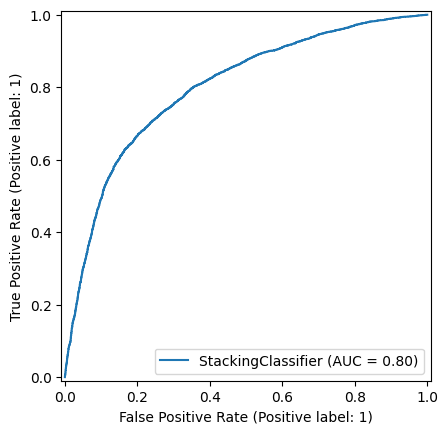

In [43]:
# ROC Curve
RocCurveDisplay.from_estimator(stacking_clf, x_test, y_test)
plt.show()

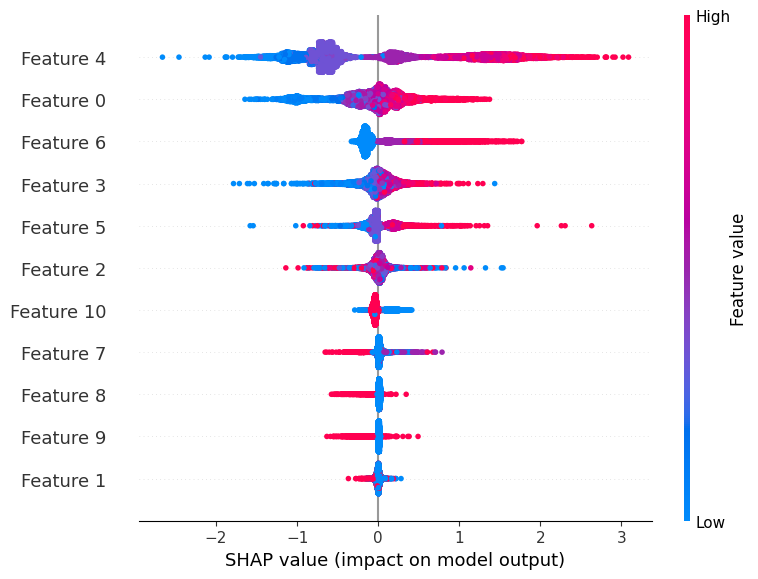

In [106]:
ada_XGB.fit(x_train, y_train) # Fit the XGBoost model
explainer = shap.TreeExplainer(ada_XGB)
shap_values = explainer.shap_values(x_test)
shap.summary_plot(shap_values, x_test)